In [18]:
# =============================
# IMPORT LIBRARIES
# =============================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

In [19]:
# =============================
# Load Cleaned Dataset
# =============================

dataset = pd.read_csv("../config/Algerian_forest_fires_dataset_CLEANED.csv")

dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012.0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012.0,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012.0,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012.0,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012.0,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [20]:
# =============================
# Drop Unnecessary Columns
# =============================
dataset.drop(["month", "day", "year"], axis=1, inplace=True)

dataset.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [21]:
# =============================
# Encode Classes Column
# =============================

dataset["Classes"] = np.where(dataset["Classes"].str.contains("not fire"), 0, 1)

dataset.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [22]:
# =============================
# Split Features and Target
# =============================

# Independent and dependent features

X = dataset.drop("FWI", axis=1)

y = dataset["FWI"]

X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [23]:
# =============================
# Train Test Split
# =============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((194, 11), (49, 11))

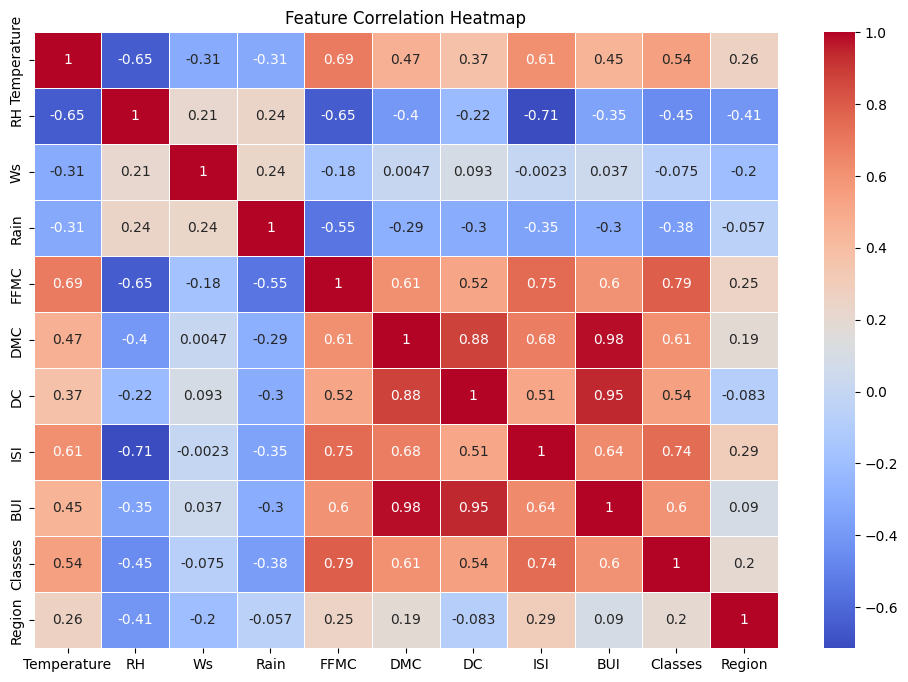

In [24]:
# =============================
# Correlation Heatmap
# =============================

plt.figure(figsize=(12, 8))

corr = X_train.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

In [25]:
# =============================
# Correlation Function
# =============================

# Function to identify highly correlated features


def correlation(dataset, threshold):
    col_corr = set()

    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]

                col_corr.add(colname)

    print(f"Highly correlated features: {col_corr}")

    return col_corr

In [26]:
# ===================================
# Remove Highly Correlated Features
# ===================================

corr_features = correlation(X_train, 0.85)

X_train.drop(corr_features, axis=1, inplace=True)

X_test.drop(corr_features, axis=1, inplace=True)

Highly correlated features: {'DC', 'BUI'}


In [27]:
# =======================
# Standard Scaling
# =======================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'After Scaling')

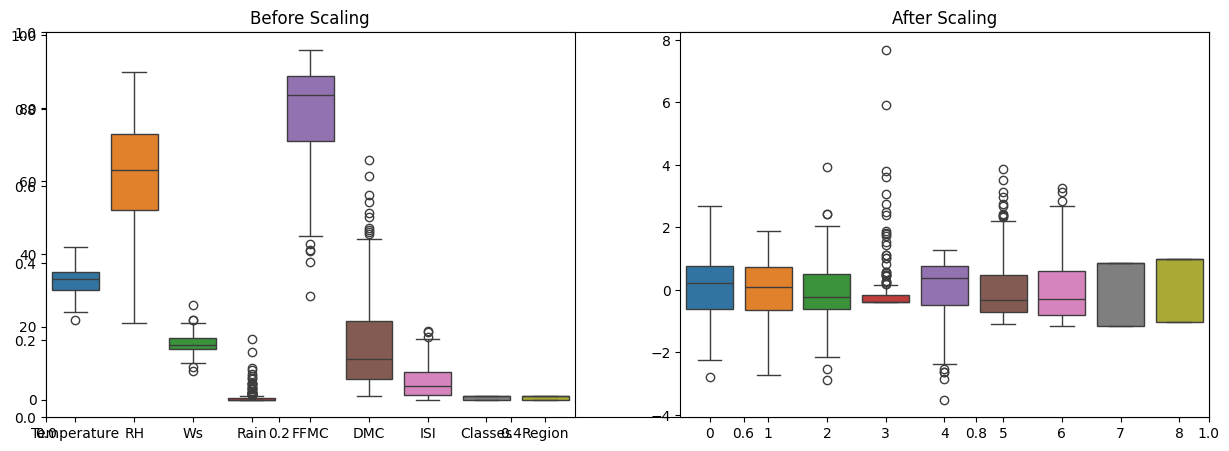

In [28]:
# =======================
# Scaling Visualization
# =======================

plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)

sns.boxplot(data=X_train)

plt.title("Before Scaling")

plt.subplot(1, 2, 2)

sns.boxplot(data=X_train_scaled)

plt.title("After Scaling")

In [29]:
# =======================
# Train Ridge Regression
# =======================

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge = Ridge()

ridge.fit(X_train_scaled, y_train)

y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r_score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")

print(f"Mean Squared Error: {mse}")

print(f"R^2 Score: {r_score}")

Mean Absolute Error: 0.5192048325844728
Mean Squared Error: 0.6029616070548557
R^2 Score: 0.9801058063273602


Text(0.5, 1.0, 'Actual vs Predicted')

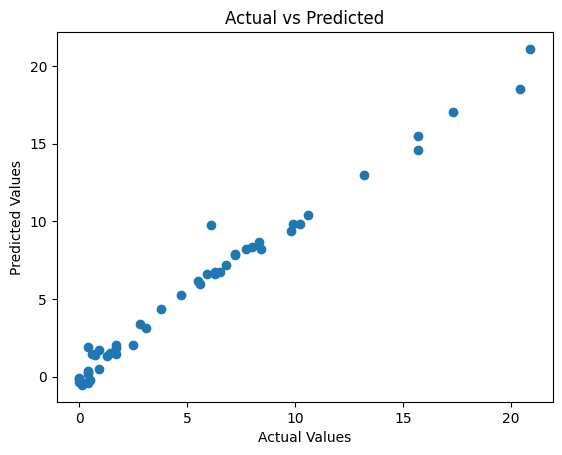

In [30]:
# ==========================
# Prediction Scatter Plot
# ==========================

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

In [31]:
# ==========================
# RidgeCV Model
# ==========================

from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 50)

ridgeCV = RidgeCV(alphas=alphas, cv=5)

ridgeCV.fit(X_train_scaled, y_train)

y_pred = ridgeCV.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r_score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")

print(f"Mean Squared Error: {mse}")

print(f"R^2 Score: {r_score}")

print(f"Best Alpha: {ridgeCV.alpha_}")

Mean Absolute Error: 0.590296599401277
Mean Squared Error: 0.6838413665423366
R^2 Score: 0.9774372490251801
Best Alpha: 4.714866363457395


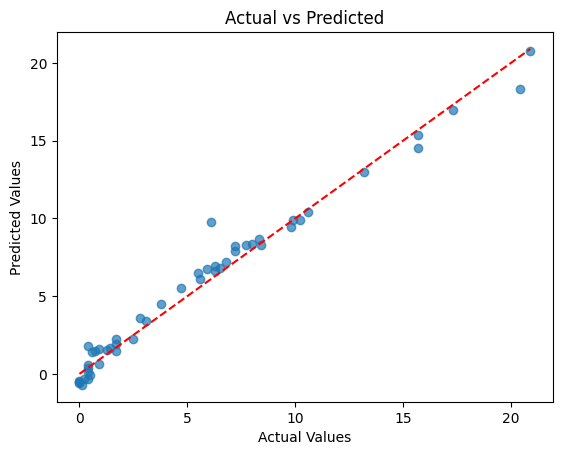

In [32]:
# ==========================
# Final Prediction Plot
# ==========================

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
)

plt.show()

In [33]:
# ==========================
# Save Model and Scaler
# ==========================

import pickle

# Save trained RidgeCV model

with open("../models/ridge.pkl", "wb") as file:
    pickle.dump(ridgeCV, file)

# Save scaler

with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("ridge.pkl and scaler.pkl saved successfully")

ridge.pkl and scaler.pkl saved successfully
